In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cmdstanpy import CmdStanModel
from pathlib import Path
import scipy.stats as st
import os

from joblib import Parallel, delayed
from tqdm.auto import tqdm
import traceback
import ast

from __future__ import annotations
from dataclasses import dataclass
from typing import Any, Dict, Optional

### Prior predictive check

If parameters are drawn only from the prior (before seeing data), does the model generate biologically plausible RNA-seq counts?

Just simulate parameters from the generative model implied by the priors.


In [3]:
def simulate_from_prior(
    N=200,
    S=2,
    seed=123
):
    rng = np.random.default_rng(seed)

    # sample-level covariates (reasonable defaults)
    subtype_idx = rng.integers(0, S, size=N)
    sf = rng.lognormal(mean=0.0, sigma=0.3, size=N)
    purity = rng.beta(5, 2, size=N)  # skewed toward tumor-rich
    copies = rng.choice([1,2,3,4,5], size=N, p=[0.15, 0.5, 0.15, 0.10, 0.10])

    dose_log = np.log(np.clip(copies, 1, None) / 2.0)
    dev = (copies - 2.0) / 2.0

    # -------- Draw parameters from priors --------

    b0_mean = rng.normal(5.0, 2.0)
    b0_offset = rng.normal(0, 0.5, size=S)
    b0 = b0_mean + (b0_offset - b0_offset.mean())

    b_scaling_mean = rng.normal(0.4, 0.7)
    b_scaling_offset = rng.normal(0, 0.3, size=S)
    b_scaling = b_scaling_mean + (b_scaling_offset - b_scaling_offset.mean())

    b_dev_mean = rng.normal(0.1, 0.45)
    b_dev_offset = rng.normal(0, 0.2, size=S)
    b_deviation = b_dev_mean + (b_dev_offset - b_dev_offset.mean())

    b_noncancer_log = rng.normal(np.log(5), 1.0)

    #phi = rng.exponential(0.7)
    phi = rng.lognormal(np.log(20), 0.5)

    # -------- Compute mu --------

    mu = np.zeros(N)

    for n in range(N):
        s = subtype_idx[n]

        linpred = (
            b0[s]
            + dose_log[n] * b_scaling[s]
            + dev[n] * b_deviation[s]
        )

        tumor_mu = sf[n] * purity[n] * np.exp(linpred)
        stroma_mu = sf[n] * (1 - purity[n]) * np.exp(b_noncancer_log)

        mu[n] = tumor_mu + stroma_mu

    # -------- Simulate counts --------

    r = phi
    p = r / (r + mu)
    y = rng.negative_binomial(r, p)

    return y, mu, phi

In [5]:
G = 200   # number of prior draws / genes
N = 200   # samples per gene

all_counts = []
all_log_mu = []
means = []
vars_ = []

for g in range(G):
    y, mu, phi = simulate_from_prior(N=N, S=2, seed=123+g)
    all_counts.append(y)
    all_log_mu.append(np.log1p(mu))   # log(1+mu) to keep finite at 0
    means.append(y.mean())
    vars_.append(y.var(ddof=1))

all_counts = np.concatenate(all_counts)
all_log_mu = np.concatenate(all_log_mu)
means = np.asarray(means)
vars_ = np.asarray(vars_)

In [7]:
np.mean(all_counts == 0)

0.006625

In [9]:
all_counts.max()

549478

In [11]:
np.percentile(all_counts, [50, 75, 90, 99])

array([ 136.  ,  464.25, 1423.1 , 9118.12])

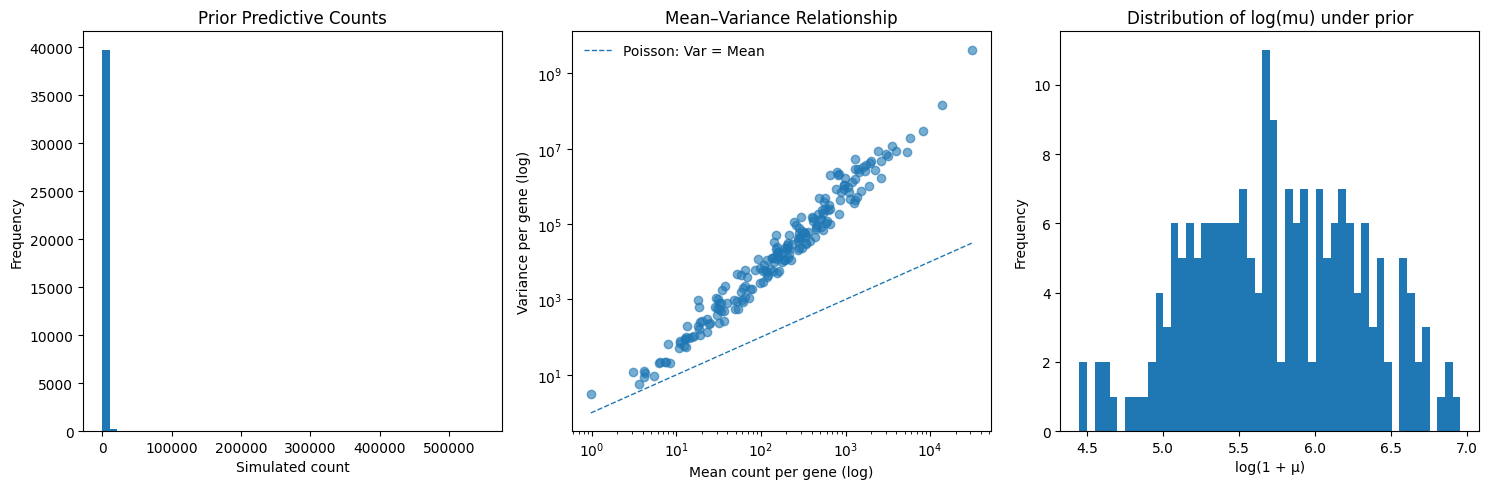

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# -------------------------------------------------
# Panel A — Histogram of Simulated Counts
# -------------------------------------------------
ax = axes[0]
ax.hist(all_counts, bins=50)
ax.set_xlabel("Simulated count")
ax.set_ylabel("Frequency")
ax.set_title("Prior Predictive Counts")

# -------------------------------------------------
# Panel B — Mean vs Variance (log–log)
# -------------------------------------------------
ax = axes[1]
ax.scatter(means, vars_, alpha=0.6)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Mean count per gene (log)")
ax.set_ylabel("Variance per gene (log)")
ax.set_title("Mean–Variance Relationship")

# Poisson reference line
valid_means = means[means > 0]
x_line = np.logspace(np.log10(valid_means.min()),
                     np.log10(valid_means.max()), 100)

ax.plot(x_line, x_line, linestyle="--", linewidth=1,
        label="Poisson: Var = Mean")
ax.legend(frameon=False)

# -------------------------------------------------
# Panel C — Distribution of log(mu)
# -------------------------------------------------
ax = axes[2]
ax.hist(np.log1p(mu), bins=50)
ax.set_xlabel("log(1 + μ)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of log(mu) under prior")

plt.tight_layout()
plt.show()

# Optional save
# plt.savefig("prior_predictive_3panel.png", dpi=300, bbox_inches="tight")

(A) Simulated count distribution under the prior.
(B) Gene-wise mean–variance relationship demonstrating negative binomial overdispersion relative to the Poisson line.
(C) Distribution of latent expression means μ induced by the hierarchical priors.

#### Compile Stan model

In [15]:
stan_path = Path("/Users/katsiarynadavydzenka/Documents/PhD_AI/DeConveil/stan/differential_dosage_model_v1.stan")
model = CmdStanModel(stan_file=str(stan_path))

#### Model simulator

In [59]:
# -----------------------------------------
# 1. SAMPLE-LEVEL COVARIATES
# -----------------------------------------
def simulate_covariates(
    N=200,
    subtype_levels=("A", "B"),
    seed=123,
    copy_probs=(0.15, 0.50, 0.15, 0.10, 0.10),
    purity_a=5.0,
    purity_b=2.0,
    sf_meanlog=0.0,
    sf_sdlog=0.2,
):
    """
    Simulate sample-level covariates shared by all genes.

    Returns
    -------
    covars : dict
        Contains N, S, subtype labels/codes, sf, purity, copies, dose_log, dev.
    """
    rng = np.random.default_rng(seed)
    subtype_levels = tuple(subtype_levels)
    S = len(subtype_levels)

    # Balanced-ish subtype assignment
    subtype_idx = rng.integers(low=0, high=S, size=N)   # 0..S-1
    subtype_labels = np.array(subtype_levels)[subtype_idx]

    # Library size factors around 1
    sf = rng.lognormal(mean=sf_meanlog, sigma=sf_sdlog, size=N)

    # Tumor purity
    purity = rng.beta(a=purity_a, b=purity_b, size=N)

    # Copy number
    copies = rng.choice(
        [1, 2, 3, 4, 5],
        size=N,
        p=np.asarray(copy_probs, dtype=float)
    ).astype(float)

    CN_eff = np.clip(copies, 1.0, None)
    dose_log = np.log(CN_eff / 2.0)
    dev = (copies - 2.0) / 2.0

    return {
        "N": N,
        "S": S,
        "subtype_levels": subtype_levels,
        "subtype_idx": subtype_idx,
        "subtype_labels": subtype_labels,
        "sf": sf,
        "purity": purity,
        "copies": copies,
        "dose_log": dose_log,
        "dev": dev,
    }


# ---------------------------------------------------
# 2. TRUE PARAMETER GENERATION BY SCENARIO
# ---------------------------------------------------

def _sum_to_zero_offsets(rng, S, sd):
    x = rng.normal(0.0, sd, size=S)
    return x - x.mean()


def simulate_gene_params(
    covars,
    rng,
    gene_id,
    scenario="mixed",
    b0_mean_loc=5.0,
    b0_mean_sd=0.7,
    b0_offset_sd=0.3,
    b_scaling_offset_sd=0.10,
    b_dev_offset_sd=0.08,
    b_noncancer_loc=np.log(5.0),
    b_noncancer_sd=0.5,
    phi_logmean=np.log(10.0),
    phi_logsd=0.25,
):
    """
    Simulate true parameters for one gene under an explicit scenario.

    Scenarios
    ---------
    null
        No CN effect.
    scaling
        Positive dosage scaling, no deviation.
    deviation_pos
        No scaling, positive deviation.
    deviation_neg
        No scaling, negative deviation.
    mixed
        Positive scaling with negative deviation (partial compensation).
    """

    S = covars["S"]

    # Tumor baseline
    b0_mean = rng.normal(b0_mean_loc, b0_mean_sd)
    b0 = b0_mean + _sum_to_zero_offsets(rng, S, b0_offset_sd)

    # Scenario-specific global means
    if scenario == "null":
        b_scaling_mean = rng.normal(0.0, 0.05)
        b_dev_mean = rng.normal(0.0, 0.05)

    elif scenario == "scaling":
        b_scaling_mean = rng.normal(0.60, 0.10)
        b_dev_mean = rng.normal(0.0, 0.05)

    elif scenario == "deviation_pos":
        b_scaling_mean = rng.normal(0.0, 0.05)
        b_dev_mean = rng.normal(0.40, 0.10)

    elif scenario == "deviation_neg":
        b_scaling_mean = rng.normal(0.0, 0.05)
        b_dev_mean = rng.normal(-0.40, 0.10)

    elif scenario == "mixed":
        b_scaling_mean = rng.normal(0.50, 0.10)
        b_dev_mean = rng.normal(-0.25, 0.10)

    else:
        raise ValueError(
            "scenario must be one of: "
            "'null', 'scaling', 'deviation_pos', 'deviation_neg', 'mixed'"
        )

    # Subtype-specific deviations around global means
    b_scaling = b_scaling_mean + _sum_to_zero_offsets(rng, S, b_scaling_offset_sd)
    b_deviation = b_dev_mean + _sum_to_zero_offsets(rng, S, b_dev_offset_sd)

    # Non-tumor baseline
    b_noncancer_log = rng.normal(b_noncancer_loc, b_noncancer_sd)

    # NB dispersion
    phi = float(np.exp(rng.normal(phi_logmean, phi_logsd)))

    return {
        "gene": gene_id,
        "scenario": scenario,
        "b0": b0,
        "b_scaling": b_scaling,
        "b_deviation": b_deviation,
        "b_noncancer_log": b_noncancer_log,
        "phi": phi,
        "b0_mean": b0_mean,
        "b_scaling_mean": b_scaling_mean,
        "b_dev_mean": b_dev_mean,
    }


# --------------------------------------
# 3. COUNT GENERATION
# --------------------------------------

def simulate_counts_for_gene(covars, true_params, rng):
    """
    Simulate NB2 counts under the same mean structure as the Stan model.
    """

    N = covars["N"]
    subtype_idx = covars["subtype_idx"]
    sf = covars["sf"]
    purity = covars["purity"]
    dose_log = covars["dose_log"]
    dev = covars["dev"]

    b0 = true_params["b0"]
    b_scaling = true_params["b_scaling"]
    b_deviation = true_params["b_deviation"]
    b_noncancer_log = true_params["b_noncancer_log"]
    phi = true_params["phi"]

    mu = np.empty(N, dtype=float)

    for n in range(N):
        s = subtype_idx[n]  # 0-based subtype index

        linpred = (
            b0[s]
            + dose_log[n] * b_scaling[s]
            + dev[n] * b_deviation[s]
        )

        tumor_mu = sf[n] * purity[n] * np.exp(linpred)
        stroma_mu = sf[n] * (1.0 - purity[n]) * np.exp(b_noncancer_log)
        mu[n] = tumor_mu + stroma_mu

    # NB2(mu, phi) in NumPy parameterization
    # Var(y) = mu + mu^2 / phi
    r = phi
    p = r / (r + mu)
    p = np.clip(p, 1e-10, 1 - 1e-10)

    expr = rng.negative_binomial(n=r, p=p, size=N).astype(int)

    return expr, mu


# --------------------------------------
# 4. SCENARIO ASSIGNMENT
# --------------------------------------

def assign_gene_scenarios(
    G,
    scenario_probs=None,
    rng=None,
):
    """
    Assign a scenario to each gene.

    scenario_probs example:
    {
        "null": 0.25,
        "scaling": 0.25,
        "deviation_pos": 0.20,
        "deviation_neg": 0.10,
        "mixed": 0.20,
    }
    """
    if rng is None:
        rng = np.random.default_rng(123)

    if scenario_probs is None:
        scenario_probs = {
            "null": 0.30,
            "scaling": 0.30,
            "deviation_pos": 0.10,
            "deviation_neg": 0.10,
            "mixed": 0.20,
        }

    scenarios = list(scenario_probs.keys())
    probs = np.array(list(scenario_probs.values()), dtype=float)
    probs = probs / probs.sum()

    return rng.choice(scenarios, size=G, p=probs)


# -----------------------------------------
# 5. MULTI-GENE DATASET SIMULATION
# -----------------------------------------

def simulate_dataset_multi_gene(
    G=100,
    N=200,
    subtype_levels=("A", "B"),
    seed=123,
    scenario_probs=None,
):
    """
    Simulate a multi-gene dataset with explicit biological scenarios.

    Returns
    -------
    sim_df : pd.DataFrame
        Long-format observed data for model fitting.
    truth_df : pd.DataFrame
        True parameter values per gene.
    covars : dict
        Shared sample-level covariates.
    """
    rng = np.random.default_rng(seed)

    # Shared sample-level design
    covars = simulate_covariates(
        N=N,
        subtype_levels=subtype_levels,
        seed=seed,
    )

    scenario_vec = assign_gene_scenarios(
        G=G,
        scenario_probs=scenario_probs,
        rng=rng,
    )

    all_rows = []
    truth_rows = []

    for g in range(G):
        gene_id = f"G{g+1}"
        scenario = scenario_vec[g]

        # true params
        true_g = simulate_gene_params(
            covars=covars,
            rng=rng,
            gene_id=gene_id,
            scenario=scenario,
        )

        # counts
        expr, mu = simulate_counts_for_gene(covars, true_g, rng)

        # observed long-format data
        df_g = pd.DataFrame({
            "gene": gene_id,
            "scenario": scenario,
            "sample_id": np.arange(covars["N"]),
            "expr": expr,
            "copies": covars["copies"],
            "purity": covars["purity"],
            "sf": covars["sf"],
            "subtype": covars["subtype_labels"],
            "subtype_idx": covars["subtype_idx"] + 1,  # 1-based for Stan convenience
            "dose_log": covars["dose_log"],
            "dev": covars["dev"],
            "mu_true": mu,
        })
        all_rows.append(df_g)

        # truth table
        row_truth = {
            "gene": gene_id,
            "scenario": scenario,
            "phi_true": true_g["phi"],
            "b_noncancer_log_true": true_g["b_noncancer_log"],
            "b0_mean_true": true_g["b0_mean"],
            "b_scaling_mean_true": true_g["b_scaling_mean"],
            "b_dev_mean_true": true_g["b_dev_mean"],
        }

        for s, lvl in enumerate(covars["subtype_levels"], start=1):
            row_truth[f"subtype_s{s}"] = lvl
            row_truth[f"b0_s{s}_true"] = true_g["b0"][s - 1]
            row_truth[f"b_scaling_s{s}_true"] = true_g["b_scaling"][s - 1]
            row_truth[f"b_deviation_s{s}_true"] = true_g["b_deviation"][s - 1]

        truth_rows.append(row_truth)

    sim_df = pd.concat(all_rows, ignore_index=True)
    truth_df = pd.DataFrame(truth_rows)

    return sim_df, truth_df, covars


# -----------------------------------------------
# 6. OPTIONAL: FIXED-SCENARIO DATASET
# -----------------------------------------------

def simulate_dataset_one_scenario(
    G=100,
    N=200,
    scenario="null",
    subtype_levels=("A", "B"),
    seed=123,
):
    """
    Simulate G genes all under the same scenario.
    Useful for separate validation blocks.
    """
    return simulate_dataset_multi_gene(
        G=G,
        N=N,
        subtype_levels=subtype_levels,
        seed=seed,
        scenario_probs={scenario: 1.0},
    )


# ---------------------------------------
# 7. QUICK SUMMARY HELPERS
# ---------------------------------------

def summarize_simulated_truth(truth_df):
    cols = [
        "b0_mean_true",
        "b_scaling_mean_true",
        "b_dev_mean_true",
        "phi_true",
    ]
    return truth_df.groupby("scenario")[cols].agg(["mean", "std", "min", "max"])


def summarize_simulated_counts(sim_df):
    return (
        sim_df.groupby(["scenario", "gene"], as_index=False)
        .agg(
            mean_expr=("expr", "mean"),
            var_expr=("expr", "var"),
            zero_frac=("expr", lambda x: np.mean(np.asarray(x) == 0)),
            mean_mu_true=("mu_true", "mean"),
        )
    )


In [61]:
# Simulate 200 genes
if __name__ == "__main__":
    sim_df, truth_df, covars = simulate_dataset_multi_gene(
        G=400,
        N=200,
        subtype_levels=("A", "B"),
        seed=123,
        scenario_probs={
            "null": 0.30,
            "scaling": 0.30,
            "deviation_pos": 0.10,
            "deviation_neg": 0.10,
            "mixed": 0.20,
        },
    )

In [25]:
print(sim_df.head())

  gene       scenario  sample_id  expr  copies    purity        sf subtype  \
0   G1  deviation_pos          0   363     2.0  0.855678  0.790778       A   
1   G1  deviation_pos          1   334     2.0  0.661651  1.179694       B   
2   G1  deviation_pos          2   623     4.0  0.758478  1.185381       B   
3   G1  deviation_pos          3   302     2.0  0.796433  0.901988       A   
4   G1  deviation_pos          4   517     2.0  0.844986  1.393227       B   

   subtype_idx  dose_log  dev     mu_true  
0            1  0.000000  0.0  364.166916  
1            2  0.000000  0.0  284.532756  
2            2  0.693147  1.0  508.194644  
3            1  0.000000  0.0  386.884685  
4            2  0.000000  0.0  427.519379  


In [46]:
truth_df.head()

,gene,scenario,phi_true,b_noncancer_log_true,b0_mean_true,b_scaling_mean_true,b_dev_mean_true,subtype_s1,b0_s1_true,b_scaling_s1_true,b_deviation_s1_true,subtype_s2,b0_s2_true,b_scaling_s2_true,b_deviation_s2_true
0,G1,deviation_pos,9.440512,1.438603,6.089785,0.026491,0.409485,A,6.286890,0.015448,0.402803,B,5.892680,0.037534,0.416168
1,G2,null,11.376886,2.336599,4.908900,0.013743,-0.011589,A,4.937146,0.097322,0.108109,B,4.880654,-0.069835,-0.131287
2,G3,null,14.083356,2.040824,4.988325,0.007511,-0.147998,A,5.418796,-0.009917,-0.113294,B,4.557855,0.024938,-0.182702
3,G4,null,10.459997,2.540500,3.792916,0.032013,0.003074,A,4.141345,0.059051,0.028388,B,3.444487,0.004976,-0.022241
4,G5,null,15.106635,1.718042,5.454327,-0.012945,-0.015478,A,5.497156,-0.003946,0.129280,B,5.411498,-0.021944,-0.160237


In [29]:
 print(truth_df["scenario"].value_counts())

scenario
null             132
scaling          118
mixed             76
deviation_neg     43
deviation_pos     31
Name: count, dtype: int64


In [31]:
print(summarize_simulated_truth(truth_df))

              b0_mean_true                               b_scaling_mean_true  \
                      mean       std       min       max                mean   
scenario                                                                       
deviation_neg     4.941434  0.636437  3.395771  6.396672            0.002417   
deviation_pos     4.990460  0.721104  3.339657  6.089785           -0.000975   
mixed             4.978495  0.587883  3.691380  5.990990            0.480439   
null              4.997436  0.762787  3.111554  6.836123           -0.003932   
scaling           4.947280  0.705157  3.129852  6.934226            0.593511   

                                            b_dev_mean_true            \
                    std       min       max            mean       std   
scenario                                                                
deviation_neg  0.050982 -0.108288  0.113376       -0.393771  0.105422   
deviation_pos  0.049788 -0.132342  0.113923        0.394116  0.1022

In [33]:
count_summary = summarize_simulated_counts(sim_df)
print(count_summary.head())

        scenario  gene  mean_expr      var_expr  zero_frac  mean_mu_true
0  deviation_neg  G111    127.300   2701.638191        0.0    126.509214
1  deviation_neg  G119    160.895   9774.134648        0.0    161.720030
2  deviation_neg  G136    307.615  31239.072136        0.0    312.723769
3  deviation_neg  G146     87.135   1891.283191        0.0     85.673247
4  deviation_neg   G15     45.175    727.632538        0.0     47.278272


In [35]:
sim_df.head()

,gene,scenario,sample_id,expr,copies,purity,sf,subtype,subtype_idx,dose_log,dev,mu_true
0,G1,deviation_pos,0,363,2.0,0.855678,0.790778,A,1,0.000000,0.0,364.166916
1,G1,deviation_pos,1,334,2.0,0.661651,1.179694,B,2,0.000000,0.0,284.532756
2,G1,deviation_pos,2,623,4.0,0.758478,1.185381,B,2,0.693147,1.0,508.194644
3,G1,deviation_pos,3,302,2.0,0.796433,0.901988,A,1,0.000000,0.0,386.884685
4,G1,deviation_pos,4,517,2.0,0.844986,1.393227,B,2,0.000000,0.0,427.519379


#### Model fit function

In [41]:
def fit_one_gene_de(
    gene_df: pd.DataFrame,
    model: "CmdStanModel",
    gene: str | None = None,
    cna: str = "all",
    et: float = 0.15,
    min_aneup: int = 5,
    min_unique_counts: int = 5,
    min_cn_abs_sum: float = 1.0,
    subtype_col: str = "subtype",
    subtype_order: list[str] | None = None,
    chains: int = 4,
    iter_warmup: int = 1000,
    iter_sampling: int = 1000,
    seed: int = 1,
    show_progress: bool = False,
    adapt_delta: float = 0.9,
    max_treedepth: int = 12,
    rope_logfc: float = float(np.log(1.2)),
    eps_frac: float = 0.10,             # ROPE on fracCN for ~10% change
    return_all_subtypes: bool = True,
    engine: str = "nuts",               # "nuts", "vi_meanfield", "vi_fullrank"
    vi_iter: int = 20000,
    vi_output_samples: int = 2000,
    vi_elbo_samples: int = 100,
    vi_grad_samples: int = 1,
    return_ppc: bool = False,
):
    """
    Fit the Bayesian differential gene-dosage model for a single gene.

    Required columns in gene_df:
        expr, copies, purity, sf, subtype_col
    Optional:
        gene (if gene_df contains multiple genes)

    Stan model is the log-link CN-expression model with generated quantities:
        delta_tumor0_log, delta_scaling, delta_dev,
        lp_2to1[s], lp_2to3[s], lp_2to4[s],
        (and optionally fracCN_*, cancel_index_*, p_DC_* if you added them).
    """

    df = gene_df.copy()

    # ---- subset gene ----
    if gene is not None and "gene" in df.columns and df["gene"].nunique() > 1:
        df = df.loc[df["gene"] == gene].copy()
    if gene is None and "gene" in df.columns and df["gene"].nunique() == 1:
        gene = str(df["gene"].iloc[0])

    if df.empty:
        return {"status": "skipped", "gene": gene, "reason": "no_rows_for_gene"}

    required = {"expr", "copies", "purity", "sf", subtype_col}
    missing = required - set(df.columns)
    if missing:
        return {"status": "error", "gene": gene, "reason": f"missing_columns: {sorted(missing)}"}

    # ---- CNA subset ----
    if cna == "amp":
        df = df[df["copies"] > (2 - et)]
    elif cna == "del":
        df = df[df["copies"] < (2 + et)]
    elif cna == "all":
        pass
    else:
        raise ValueError("cna must be 'amp', 'del', or 'all'")

    if df.empty:
        return {"status": "skipped", "gene": gene, "reason": "no_samples_after_cna_filter"}

    # ---- basic QC ----
    df = df.dropna(subset=list(required))
    if df.empty:
        return {"status": "skipped", "gene": gene, "reason": "all_na_after_dropna"}

    if (df["expr"] < 0).any():
        return {"status": "error", "gene": gene, "reason": "negative_counts"}

    if not df["purity"].between(0, 1).all():
        return {"status": "error", "gene": gene, "reason": "purity_out_of_bounds"}

    if not (df["sf"] > 0).all():
        return {"status": "error", "gene": gene, "reason": "nonpositive_sf"}

    if df["expr"].nunique() < min_unique_counts:
        return {"status": "skipped", "gene": gene, "reason": "too_few_unique_counts"}

    # aneuploid count check
    n_aneup = int((np.abs(df["copies"].astype(float) - 2.0) > (1.0 - et)).sum())
    if n_aneup < min_aneup or (df["expr"] == 0).all():
        return {
            "status": "skipped",
            "gene": gene,
            "n_aneup": n_aneup,
            "reason": "low_aneup_or_all_zero",
        }

    # identifiability check: need some CN deviation mass
    dev_tmp = (df["copies"].astype(float) - 2.0) / 2.0
    if cna == "all" and float(np.abs(dev_tmp).sum()) < min_cn_abs_sum:
        return {
            "status": "skipped",
            "gene": gene,
            "n_aneup": n_aneup,
            "reason": "too_little_cn_variation",
        }

    # ---- subtype encoding -----
    if subtype_order is not None:
        cat = pd.Categorical(df[subtype_col], categories=subtype_order, ordered=True)
        if cat.isna().any():
            bad = df.loc[cat.isna(), subtype_col].unique().tolist()
            return {
                "status": "error",
                "gene": gene,
                "reason": f"unknown_subtypes: {bad}",
            }
        subtype_codes = (cat.codes + 1).astype(int)
        levels = list(cat.categories)
    else:
        levels = sorted(pd.unique(df[subtype_col]).tolist())
        mapping = {lv: i + 1 for i, lv in enumerate(levels)}
        subtype_codes = df[subtype_col].map(mapping).astype(int).to_numpy()

    S = len(levels)
    if S < 2:
        return {
            "status": "skipped",
            "gene": gene,
            "reason": "need_at_least_2_subtypes_present_for_DE",
        }

    # ---- CN covariates (identified) ----
    # effective CN for scaling: treat 0 and 1 as "1 copy"
    CN_eff = df["copies"].astype(float).clip(lower=1.0)
    #df["dose_log"] = np.log(np.maximum(df["copies"].astype(float), 0.1) / 2.0)
    df["dose_log"] = np.log(CN_eff / 2.0)
    df["dev"] = (df["copies"].astype(float) - 2.0) / 2.0

    stan_data = {
        "N": int(len(df)),
        "y": df["expr"].astype(int).to_numpy(),
        "S": int(S),
        "subtype": np.asarray(subtype_codes, dtype=int),
        "sf": df["sf"].to_numpy(dtype=float),
        "purity": df["purity"].to_numpy(dtype=float),
        "dose_log": df["dose_log"].to_numpy(dtype=float),
        "dev": df["dev"].to_numpy(dtype=float),
    }

    # ---- initial values for NUTS ----
    rng = np.random.default_rng(seed)
    phi_init = rng.exponential(1.0)
    phi_init = float(np.clip(phi_init, 1e-3, 100.0))
    init_nuts = {
        # global means
        "b0_mean": float(rng.normal(0.0, 0.2)),
        "b_scaling_mean": float(rng.normal(0.0, 0.2)),
        "b_dev_mean": float(rng.normal(0.0, 0.05)),
        
        "b0_offset": rng.normal(0.0, 0.1, size=S).tolist(),
        "b_scaling_offset": rng.normal(0.0, 0.1, size=S).tolist(),
        "b_dev_offset": rng.normal(0.0, 0.05, size=S).tolist(),
        
        # stromal baseline
        "b_noncancer_log": float(rng.normal(0.0, 0.2)),
        
        # dispersion 
        "phi": phi_init
    }

    # ---- inference engine ----
    engine = engine.lower()
    if engine == "nuts":
        fit = model.sample(
            data=stan_data,
            chains=chains,
            iter_warmup=iter_warmup,
            iter_sampling=iter_sampling,
            seed=seed,
            inits=init_nuts,
            show_progress=show_progress,
            adapt_delta=adapt_delta,
            max_treedepth=max_treedepth,
        )
        draws = fit.draws_pd()
        using_mcmc = True

    elif engine in {"vi_meanfield", "vi_fullrank"}:
        algo = "meanfield" if engine == "vi_meanfield" else "fullrank"

        # NOTE: CmdStan's variational inits arg is a *float range*, not a dict.
        # We'll just let Stan pick its default random init unless you want to
        # pass a scalar, e.g. inits=0.1.
        fit = model.variational(
            data=stan_data,
            seed=seed,
            algorithm=algo,
            iter=vi_iter,
            grad_samples=vi_grad_samples,
            elbo_samples=vi_elbo_samples,
            output_samples=vi_output_samples,
            show_console=show_progress,
        )
        # VI: build a DataFrame manually
        # variational_sample: array of shape (draws, num_params)
        draws_np = fit.variational_sample
        colnames = fit.column_names    # e.g. ["b0_mean", "b0[1]", "b0[2]", ...]
        draws = pd.DataFrame(draws_np, columns=colnames)
        using_mcmc = False

    else:
        raise ValueError("engine must be 'nuts', 'vi_meanfield', or 'vi_fullrank'")

    # ---- helpers ----
    def q(x: np.ndarray) -> list[float]:
        return np.quantile(x, [0.025, 0.5, 0.975]).tolist()

    def summarize_draw(x: np.ndarray, prefix: str) -> dict:
        qi = q(x)
        return {
            f"{prefix}_median": float(qi[1]),
            f"{prefix}_q025": float(qi[0]),
            f"{prefix}_q975": float(qi[2]),
        }

    # ---- check essential columns ----
    required_cols = [
        "delta_tumor0_log",
        "delta_scaling",
        "delta_dev",
        "phi",
        "b_noncancer_log",
    ]
    missing_cols = [c for c in required_cols if c not in draws.columns]
    if missing_cols:
        return {
            "status": "error",
            "gene": gene,
            "reason": f"missing_draws_columns: {missing_cols}",
        }

    # ---- contrasts ----
    d_tumor = draws["delta_tumor0_log"].to_numpy()
    d_scal = draws["delta_scaling"].to_numpy()
    d_dev = draws["delta_dev"].to_numpy()

    # sign probabilities & lfsr
    p_up_tumor = float((d_tumor > 0).mean())
    lfsr_tumor = float(min(p_up_tumor, 1.0 - p_up_tumor))
    p_rope_tumor = float((np.abs(d_tumor) <= rope_logfc).mean())

    p_up_scal = float((d_scal > 0).mean())
    lfsr_scal = float(min(p_up_scal, 1.0 - p_up_scal))

    p_up_dev = float((d_dev > 0).mean())
    lfsr_dev = float(min(p_up_dev, 1.0 - p_up_dev))

    # log2 fold-change for tumor baseline DE
    ln2 = np.log(2.0)
    lfc_tumor = d_tumor / ln2
    lfc_ci = q(lfc_tumor) # [q025, median, q975]
    # precompute CIs for deltas
    d_scal_ci = q(d_scal)
    d_dev_ci = q(d_dev)

    phi_arr = draws["phi"].to_numpy()
    phi_ci = q(phi_arr)

    out: dict[str, object] = {
        "status": "ok",
        "gene": gene,
        "N": int(len(df)),
        "n_aneup": n_aneup,
        "cna": cna,
        "subtype_levels": levels,

        # tumor baseline DE at CN=2 (log2 scale)
        "tumor0_lfc_median": float(lfc_ci[1]),
        "tumor0_lfc_q025": float(lfc_ci[0]),
        "tumor0_lfc_q975": float(lfc_ci[2]),
        "p_up_tumor": p_up_tumor,
        "lfsr_tumor": lfsr_tumor,
        "p_rope_tumor": p_rope_tumor,

        # differential CN wiring between subtypes (delta_scaling)
        "delta_scaling_median": float(d_scal_ci[1]),
        "delta_scaling_q025": float(d_scal_ci[0]),
        "delta_scaling_q975": float(d_scal_ci[2]),
        "p_up_scaling": p_up_scal,
        "lfsr_scaling": lfsr_scal,

        # deviation contrast
        "delta_dev_median": float(d_dev_ci[1]),
        "delta_dev_q025": float(d_dev_ci[0]),
        "delta_dev_q975": float(d_dev_ci[2]),
        "p_up_dev": p_up_dev,
        "lfsr_dev": lfsr_dev,

        # dispersion
        "phi_median": float(phi_ci[1]),
        "phi_q025": float(phi_ci[0]),
        "phi_q975": float(phi_ci[2]),
    }

    # ---- subtype-specific coefficients & dosage summaries -----
    s_iter = range(1, S + 1) if return_all_subtypes else range(1, min(S, 2) + 1)

    for s in s_iter:
        # coefficients b0, b_scaling, b_deviation
        for base in ["b0", "b_scaling", "b_deviation"]:
            col = f"{base}[{s}]"
            if col in draws.columns:
                arr = draws[col].to_numpy()
                out.update(summarize_draw(arr, f"{base}_s{s}"))

        # canonical CN transitions
        col21 = f"lp_2to1[{s}]"
        col23 = f"lp_2to3[{s}]"
        col24 = f"lp_2to4[{s}]"

        if col21 in draws.columns:
            lp21 = draws[col21].to_numpy()
            out.update(summarize_draw(lp21, f"lp_2to1_s{s}"))
            frac21 = np.expm1(lp21)
            out.update(summarize_draw(frac21, f"fracCN_2to1_s{s}"))
            out[f"p_fracCN_2to1_pos_s{s}"] = float((frac21 > eps_frac).mean())
            out[f"p_fracCN_2to1_rope_s{s}"] = float((np.abs(frac21) <= eps_frac).mean())
            out[f"p_fracCN_2to1_neg_s{s}"] = float((frac21 < -eps_frac).mean())

        if col23 in draws.columns:
            lp23 = draws[col23].to_numpy()
            out.update(summarize_draw(lp23, f"lp_2to3_s{s}"))
            frac23 = np.expm1(lp23)
            out.update(summarize_draw(frac23, f"fracCN_2to3_s{s}"))
            out[f"p_fracCN_2to3_pos_s{s}"] = float((frac23 > eps_frac).mean())
            out[f"p_fracCN_2to3_rope_s{s}"] = float((np.abs(frac23) <= eps_frac).mean())
            out[f"p_fracCN_2to3_neg_s{s}"] = float((frac23 < -eps_frac).mean())

        if col24 in draws.columns:
            lp24 = draws[col24].to_numpy()
            out.update(summarize_draw(lp24, f"lp_2to4_s{s}"))
            frac24 = np.expm1(lp24)
            out.update(summarize_draw(frac24, f"fracCN_2to4_s{s}"))
            out[f"p_fracCN_2to4_pos_s{s}"] = float((frac24 > eps_frac).mean())
            out[f"p_fracCN_2to4_rope_s{s}"] = float((np.abs(frac24) <= eps_frac).mean())
            out[f"p_fracCN_2to4_neg_s{s}"] = float((frac24 < -eps_frac).mean())

        # Optional: if you added cancel_index_2to*, p_DC_* in Stan, they will be
        # present in draws and you can either pick them up here or classify later
        # from lp_scaling_* and lp_dev_*.

        # Also summarize lp_scaling_* and lp_dev_* if present (useful for diagnostics)
        for trans in ["2to1", "2to3", "2to4"]:
            for comp in ["scaling", "dev"]:
                col = f"lp_{comp}_{trans}[{s}]"
                if col in draws.columns:
                    arr = draws[col].to_numpy()
                    out.update(summarize_draw(arr, f"lp_{comp}_{trans}_s{s}"))

    
    # ---- Posterior predictive extraction ----
    if return_ppc:
        y_obs = df["expr"].to_numpy()
        yrep_cols = [c for c in draws.columns if c.startswith("y_rep[")]

        if len(yrep_cols) > 0:
            y_rep_mat = draws[yrep_cols].to_numpy()

            out["ppc_summary"] = {
                "obs_mean": float(y_obs.mean()),
                "obs_var": float(y_obs.var(ddof=1)),
                "obs_zero_frac": float((y_obs == 0).mean()),
                "ppc_mean_median": float(np.median(y_rep_mat.mean(axis=1))),
                "ppc_var_median": float(np.median(y_rep_mat.var(axis=1, ddof=1))),
                "ppc_zero_frac_median": float(
                    np.median((y_rep_mat == 0).mean(axis=1))
                ),
            }

            out["ppc_draws"] = y_rep_mat

    # ---- Sampler diagnostics (for model checking) ----
    if using_mcmc:
        summ = fit.summary()
        rhat_col = next((c for c in ["R_hat", "Rhat"] if c in summ.columns), None)
        ess_col = next((c for c in ["Ess_bulk", "ESS_bulk", "N_Eff", "Ess"] if c in summ.columns), None)

        # Rhat / ESS for phi 
        if rhat_col and "phi" in summ.index:
            out["Rhat_phi"] = float(summ.loc["phi", rhat_col])
        if ess_col and "phi" in summ.index:
            out["ess_phi"] = float(summ.loc["phi", ess_col])

        # Rhat / ESS over a core set of parameters (for global diagnostics)
        core_params = ["delta_tumor0_log", "delta_scaling", "delta_dev"]
        for s in s_iter:
            core_params += [f"b0[{s}]", f"b_scaling[{s}]", f"b_deviation[{s}]"]

        core_params = [p for p in core_params if p in summ.index]

        if core_params and rhat_col and ess_col:
            rhat_vals = summ.loc[core_params, rhat_col].to_numpy(dtype=float)
            ess_vals = summ.loc[core_params, ess_col].to_numpy(dtype=float)
            out["max_Rhat_core"] = float(np.nanmax(rhat_vals))
            out["min_ESS_core"] = float(np.nanmin(ess_vals))
        else:
            out["max_Rhat_core"] = np.nan
            out["min_ESS_core"] = np.nan

        # Divergences and treedepth from sampler params (if present)
        if "divergent__" in draws.columns:
            out["n_divergent"] = int(draws["divergent__"].sum())
        if "treedepth__" in draws.columns:
            td = draws["treedepth__"].to_numpy()
            out["max_treedepth"] = int(td.max())
            out["n_max_treedepth"] = int((td >= max_treedepth).sum())

        # simple flag based on diagnostics
        out["fit_flag"] = "ok"
        if (
            ("max_Rhat_core" in out and out["max_Rhat_core"] is not np.nan and out["max_Rhat_core"] > 1.05)
            or ("min_ESS_core" in out and out["min_ESS_core"] is not np.nan and out["min_ESS_core"] < 100)
            or ("n_divergent" in out and out["n_divergent"] > 0)
        ):
            out["fit_flag"] = "warn"
    else:
        # VI: no HMC diagnostics; you can add ELBO here if you want
        out["Rhat_phi"] = np.nan
        out["ess_phi"] = np.nan
        out["max_Rhat_core"] = np.nan
        out["min_ESS_core"] = np.nan
        out["n_divergent"] = 0
        out["max_treedepth"] = 0
        out["n_max_treedepth"] = 0
        out["fit_flag"] = "ok"

    return out

In [43]:
# Compile Stan model

stan_path = Path("/Users/katsiarynadavydzenka/Documents/PhD_AI/DeConveil/stan/differential_dosage_model_v1.stan")
model = CmdStanModel(stan_file=str(stan_path))

16:51:26 - cmdstanpy - INFO - compiling stan file /Users/katsiarynadavydzenka/Documents/PhD_AI/DeConveil/stan/differential_dosage_model_v1.stan to exe file /Users/katsiarynadavydzenka/Documents/PhD_AI/DeConveil/stan/differential_dosage_model_v1
16:51:36 - cmdstanpy - INFO - compiled model executable: /Users/katsiarynadavydzenka/Documents/PhD_AI/DeConveil/stan/differential_dosage_model_v1


In [44]:
# MCMC
res_mcmc = fit_one_gene_de(
        sim_df,
        model,
        gene="G1",
        engine="nuts",
        chains=4,
        iter_warmup=1000,
        iter_sampling=1000,
        seed=123,
        show_progress=False,
        adapt_delta=0.9,
        max_treedepth=12,
        return_ppc=True
    )

16:51:37 - cmdstanpy - INFO - CmdStan start processing
16:51:37 - cmdstanpy - INFO - Chain [1] start processing
16:51:37 - cmdstanpy - INFO - Chain [2] start processing
16:51:37 - cmdstanpy - INFO - Chain [3] start processing
16:51:37 - cmdstanpy - INFO - Chain [4] start processing
17:00:12 - cmdstanpy - INFO - Chain [2] done processing
17:00:39 - cmdstanpy - INFO - Chain [1] done processing
17:00:41 - cmdstanpy - INFO - Chain [3] done processing
17:00:51 - cmdstanpy - INFO - Chain [4] done processing
17:00:51 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 990 iterations at max treedepth (99.0%)
	Chain 2 had 566 iterations at max treedepth (56.6%)
	Chain 3 had 877 iterations at max treedepth (87.7%)
	Chain 4 had 997 iterations at max treedepth (99.7%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


In [49]:
res_mcmc

{'status': 'ok',
 'gene': 'G1',
 'N': 200,
 'n_aneup': 87,
 'cna': 'all',
 'subtype_levels': ['A', 'B'],
 'tumor0_lfc_median': -0.5836848382953364,
 'tumor0_lfc_q025': -0.7170723100950633,
 'tumor0_lfc_q975': -0.4490948080442763,
 'p_up_tumor': 0.0,
 'lfsr_tumor': 0.0,
 'p_rope_tumor': 0.0,
 'delta_scaling_median': 0.003145505,
 'delta_scaling_q025': -0.432539025,
 'delta_scaling_q975': 0.43473895,
 'p_up_scaling': 0.50575,
 'lfsr_scaling': 0.49424999999999997,
 'delta_dev_median': -0.08531965,
 'delta_dev_q025': -0.434306525,
 'delta_dev_q975': 0.26259922500000005,
 'p_up_dev': 0.31925,
 'lfsr_dev': 0.31925,
 'phi_median': 10.88635,
 'phi_q025': 10.042887499999999,
 'phi_q975': 12.743905,
 'b0_s1_median': 6.300929999999999,
 'b0_s1_q025': 6.23388925,
 'b0_s1_q975': 6.3657604999999995,
 'b_scaling_s1_median': 0.1383765,
 'b_scaling_s1_q025': -0.21613607499999998,
 'b_scaling_s1_q975': 0.510145575,
 'b_deviation_s1_median': 0.367992,
 'b_deviation_s1_q025': 0.06756870250000001,
 'b_devi

In [51]:
def posterior_predictive_plots_from_result(
    res: dict,
    gene_df: pd.DataFrame,
    expr_col: str = "expr",
    gene_name: str | None = None,
    savepath: str | None = None,
):
    """
    3-panel posterior predictive check using the output dict from fit_one_gene_de.

    Panel A1: posterior predictive counts (density)
    Panel A2: observed counts (density)
    Panel B:  mean–variance (obs vs posterior predictive)
    """

    # -----------------------------
    # 1. Sanity checks & extraction
    # -----------------------------
    if "ppc_draws" not in res:
        raise ValueError(
            "res does not contain 'ppc_draws'. "
            "Call fit_one_gene_de(..., return_ppc=True)."
        )

    y_rep_mat = res["ppc_draws"]  # shape: (n_draws, N)

    if expr_col not in gene_df.columns:
        raise ValueError(f"Column '{expr_col}' not found in gene_df")

    y_obs = gene_df[expr_col].to_numpy()
    N = len(y_obs)

    if y_rep_mat.shape[1] != N:
        raise ValueError(
            f"Mismatch: ppc_draws has N={y_rep_mat.shape[1]}, "
            f"but gene_df has N={N}"
        )

    # -----------------------------
    # 2. Summaries for plotting
    # -----------------------------
    # Posterior predictive counts, flattened
    all_ppc_counts = y_rep_mat.flatten()

    # Common bins (integer-centered)
    lo = int(min(all_ppc_counts.min(), y_obs.min()))
    hi = int(max(all_ppc_counts.max(), y_obs.max()))
    bins = np.arange(lo, hi + 2) - 0.5  # centers at integers

    # Mean–variance across posterior predictive datasets
    ppc_means = y_rep_mat.mean(axis=1)
    ppc_vars = y_rep_mat.var(axis=1, ddof=1)

    obs_mean = y_obs.mean()
    obs_var = y_obs.var(ddof=1)

    # -----------------------------
    # 3. Make 3-panel figure
    # -----------------------------
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # ---- Panel A1: posterior predictive counts (density) ----
    ax = axes[0]
    ax.hist(all_ppc_counts, bins=bins, density=True, color="#1f77b4")
    ax.set_xlabel("Count")
    ax.set_ylabel("Density")
    title_A1 = "A1  Posterior predictive counts"
    if gene_name is not None:
        title_A1 += f"\nGene: {gene_name}"
    ax.set_title(title_A1)

    # ---- Panel A2: observed counts (density) ----
    ax = axes[1]
    ax.hist(y_obs, bins=bins, density=True, color="#ff7f0e")
    ax.set_xlabel("Count")
    ax.set_ylabel("Density")
    ax.set_title("A2  Observed counts")

    # ---- Panel B: mean–variance relationship ----
    ax = axes[2]

    # Posterior predictive cloud
    ax.scatter(ppc_means, ppc_vars, alpha=0.4, s=15, label="Posterior predictive")

    # Observed point
    ax.scatter(
        [obs_mean],
        [obs_var],
        color="red",
        marker="x",
        s=60,
        label="Observed",
    )

    # Poisson Var = Mean reference line
    valid_means = ppc_means[ppc_means > 0]
    if valid_means.size > 0:
        x_line = np.logspace(
            np.log10(valid_means.min()),
            np.log10(valid_means.max()),
            100,
        )
        ax.plot(
            x_line,
            x_line,
            linestyle="--",
            linewidth=1,
            label="Poisson: Var = Mean",
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Mean count (log scale)")
    ax.set_ylabel("Variance (log scale)")
    ax.set_title("B  Mean–variance: observed vs posterior predictive")
    ax.legend(frameon=False)

    plt.tight_layout()

    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")

    plt.show()

In [53]:
gene_name = "G1"
gene_df = sim_df[sim_df["gene"] == gene_name].copy()

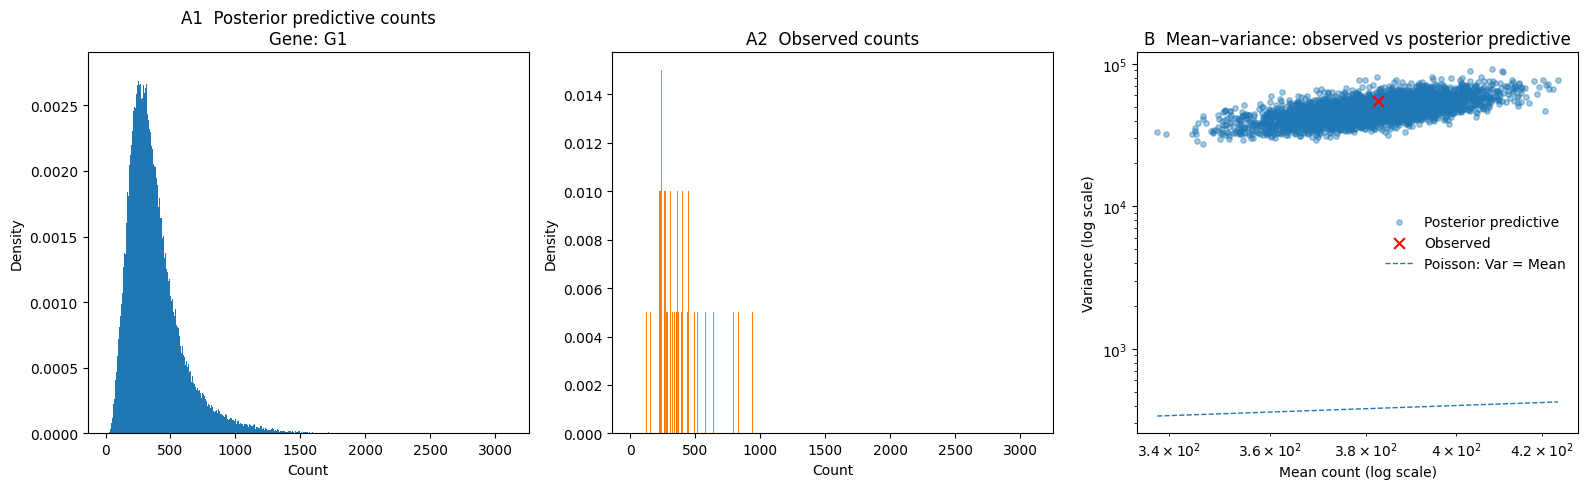

In [55]:
posterior_predictive_plots_from_result(
    res=res_mcmc,
    gene_df=gene_df,
    expr_col="expr",
    gene_name=gene_name,
    savepath=None,  
)

The posterior predictive distribution closely matches the empirical count distribution. The observed dataset lies within the predictive envelope of simulated datasets, both in terms of count magnitude and mean–variance structure. While the posterior predictive distribution exhibits slightly heavier tails, no systematic under- or over-dispersion is observed, indicating adequate calibration of the negative binomial likelihood.

Use log scale to plot:
plt.hist(np.log1p(all_ppc_counts), ...)
plt.hist(np.log1p(y_obs), ...)